In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-132.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-308.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-292.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-325.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-373.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-148.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-251.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-438.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-390.jpg
/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data/brown spots/brownspots-38.jpg
/kaggle/input/dataset

In [62]:

# Deep learning framework
import tensorflow as tf

# Keras API inside TensorFlow
from tensorflow import keras
from tensorflow.keras import layers

# MobileNetV2 pretrained model
from tensorflow.keras.applications import MobileNetV2

# Image preprocessing tools
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [63]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [64]:
# Path where Kaggle stores the dataset
data_dir = "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data"

In [65]:
print(os.listdir("/kaggle/input"))

['datasets']


In [66]:
print(os.listdir("/kaggle/input/datasets"))

['hadjerhamaidi']


In [67]:
import os

data_dir = "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data"

total_images = 0

for folder in os.listdir(data_dir):        # loop through class folders
    folder_path = os.path.join(data_dir, folder)

    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))   # count images
        
        print(f"{folder} : {num_images} images")

        total_images += num_images

print("\nTotal Images in Dataset:", total_images)

brown spots : 470 images
healthy : 1203 images
white scale : 958 images

Total Images in Dataset: 2631


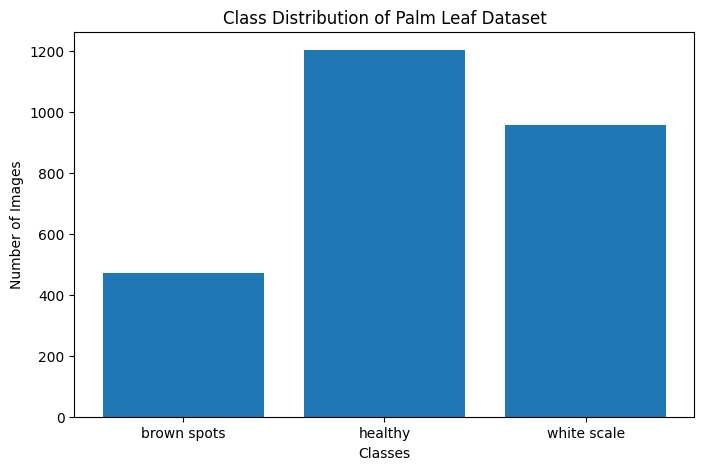

In [68]:
# Exploratory Data Analysis     
import os
import matplotlib.pyplot as plt

class_names = []
image_counts = []

for folder in os.listdir(data_dir):
    
    folder_path = os.path.join(data_dir, folder)
    
    if os.path.isdir(folder_path):
        
        num_images = len(os.listdir(folder_path))
        
        class_names.append(folder)
        
        image_counts.append(num_images)

plt.figure(figsize=(8,5))

plt.bar(class_names, image_counts)

plt.title("Class Distribution of Palm Leaf Dataset")

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.show()

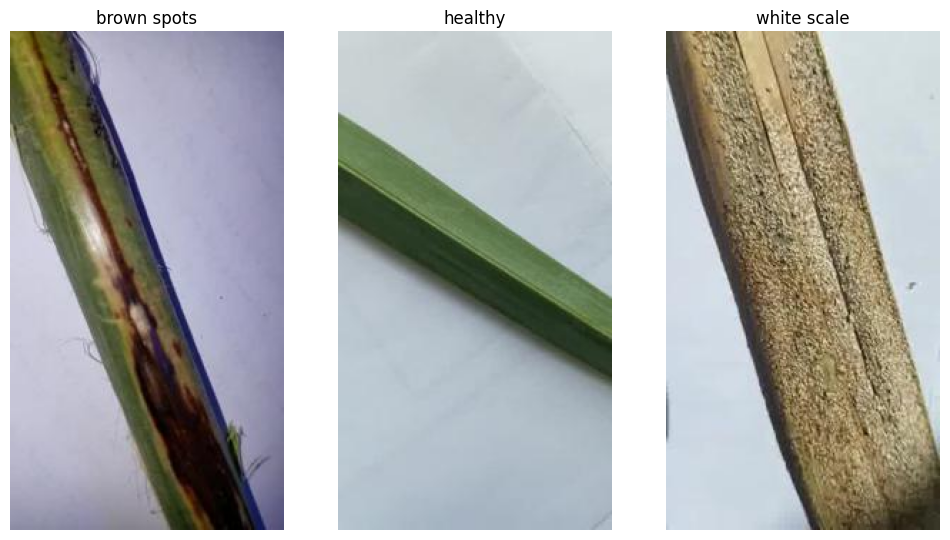

In [69]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = os.listdir(data_dir)

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    
    folder_path = os.path.join(data_dir, cls)
    
    img_name = random.choice(os.listdir(folder_path))
    
    img_path = os.path.join(folder_path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

In [70]:
from PIL import Image
import os

data_dir = "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data"

image_sizes = set()

for folder in os.listdir(data_dir):
    
    folder_path = os.path.join(data_dir, folder)
    
    for img_name in os.listdir(folder_path):
        
        img_path = os.path.join(folder_path, img_name)
        
        img = Image.open(img_path)
        
        image_sizes.add(img.size)

print("Unique Image Sizes in Dataset:")
print(image_sizes)

Unique Image Sizes in Dataset:
{(192, 350), (350, 192)}


In [15]:
# Data pre processing for MobileNetV2 

In [71]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [105]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [106]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)


In [107]:
train_data = train_datagen.flow_from_directory(
    "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    "/kaggle/input/datasets/hadjerhamaidi/date-palm-data/Date Palm data",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(train_data.class_indices)


Found 2106 images belonging to 3 classes.
Found 525 images belonging to 3 classes.
{'brown spots': 0, 'healthy': 1, 'white scale': 2}


In [108]:
print(train_data.class_indices)

{'brown spots': 0, 'healthy': 1, 'white scale': 2}


In [109]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.summary()


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [110]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    )
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 590ms/step - accuracy: 0.5022 - loss: 1.0695 - val_accuracy: 0.7314 - val_loss: 0.5728 - learning_rate: 1.0000e-04
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 406ms/step - accuracy: 0.8359 - loss: 0.4444 - val_accuracy: 0.8457 - val_loss: 0.3653 - learning_rate: 1.0000e-04
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 401ms/step - accuracy: 0.8805 - loss: 0.3028 - val_accuracy: 0.8324 - val_loss: 0.3296 - learning_rate: 1.0000e-04
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 393ms/step - accuracy: 0.9234 - loss: 0.2318 - val_accuracy: 0.8457 - val_loss: 0.2957 - learning_rate: 1.0000e-04
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 402ms/step - accuracy: 0.9507 - loss: 0.1647 - val_accuracy: 0.8438 - val_loss: 0.2880 - learning_rate: 1.0000e-04
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 407ms/step - accuracy: 0.9606 - loss: 0.1296 - val_accuracy: 0.8571 - val_loss: 0.2686 - learning_rate: 1.0000e-04
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 27s 405ms/step - acc

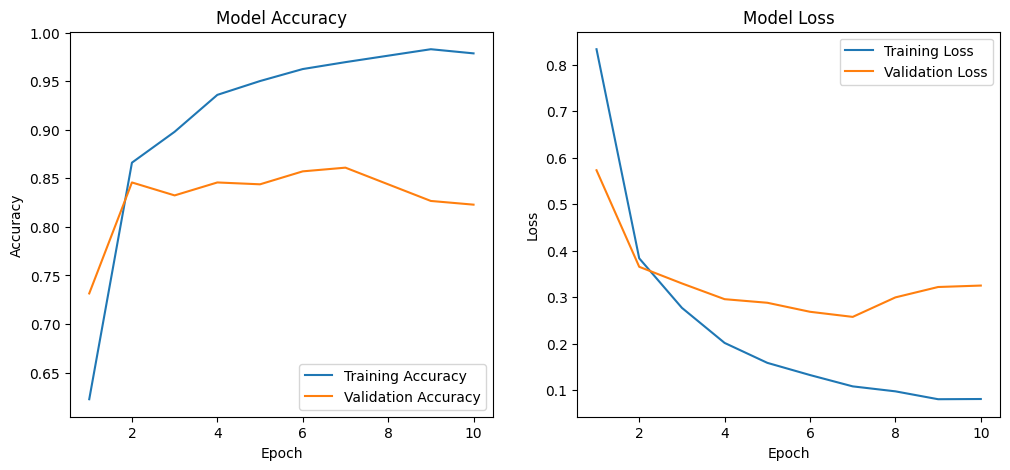

In [112]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 333ms/step


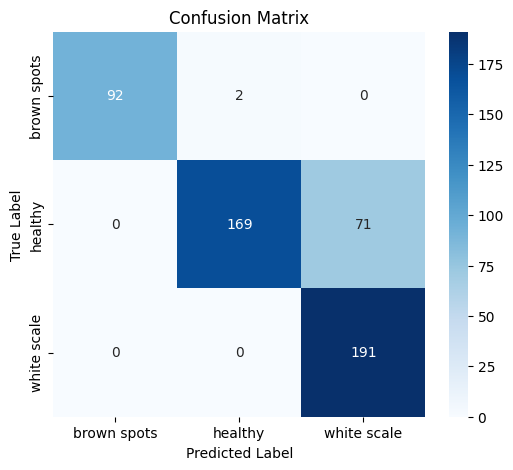

              precision    recall  f1-score   support

 brown spots       1.00      0.98      0.99        94
     healthy       0.99      0.70      0.82       240
 white scale       0.73      1.00      0.84       191

    accuracy                           0.86       525
   macro avg       0.91      0.89      0.88       525
weighted avg       0.90      0.86      0.86       525



In [113]:
val_data.reset()

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred_classes)
class_names = list(val_data.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))


In [114]:
cm = confusion_matrix(y_true, y_pred_classes)

In [116]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

 brown spots       1.00      0.98      0.99        94
     healthy       0.99      0.70      0.82       240
 white scale       0.73      1.00      0.84       191

    accuracy                           0.86       525
   macro avg       0.91      0.89      0.88       525
weighted avg       0.90      0.86      0.86       525



In [117]:
import pandas as pd

results = pd.DataFrame([
    {
        "Run": "Frozen base - original best",
        "Batch Size": 32,
        "Class Weight": "No",
        "Fine-tuning": "No",
        "Best Val Accuracy": 0.8971,
        "Best Val Loss": 0.2215,
        "Decision": "Keep"
    },
    {
        "Run": "Frozen base + class weights",
        "Batch Size": 32,
        "Class Weight": "Yes",
        "Fine-tuning": "No",
        "Best Val Accuracy": 0.8324,
        "Best Val Loss": 0.3234,
        "Decision": "Reject"
    },
    {
        "Run": "Fine-tuning last 20 layers",
        "Batch Size": 32,
        "Class Weight": "No",
        "Fine-tuning": "Yes",
        "Best Val Accuracy": 0.7810,
        "Best Val Loss": 0.4239,
        "Decision": "Reject"
    },
    {
        "Run": "Frozen base with batch size 16",
        "Batch Size": 16,
        "Class Weight": "No",
        "Fine-tuning": "No",
        "Best Val Accuracy": 0.8420,
        "Best Val Loss": 0.3000,
        "Decision": "Reject"
    }
])

results


,Run,Batch Size,Class Weight,Fine-tuning,Best Val Accuracy,Best Val Loss,Decision
0,Frozen base - original best,32,No,No,0.8971,0.2215,Keep
1,Frozen base + class weights,32,Yes,No,0.8324,0.3234,Reject
2,Fine-tuning last 20 layers,32,No,Yes,0.7810,0.4239,Reject
3,Frozen base with batch size 16,16,No,No,0.8420,0.3000,Reject


In [ ]:
# Final Note:
# MobileNetV2 achieved good training accuracy and reasonable validation accuracy
# on the palm leaf dataset. The validation curves show mild overfitting after
# several epochs, so the best model was selected using validation performance.
